In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data', header = None)

In [44]:
# •	A) sepal length B) sepal width C) petal length D) petal width
df.columns = ['sepal length', 'sepal width', 'petal length', 'petal width', 'species']
plot_data_scaled = []
plot_data = []
loss_functions = ['log_loss', 'hinge', 'modified_huber', 'squared_hinge', 'perceptron']
y = df.iloc[:, -1]
print(df.head())

   sepal length  sepal width  petal length  petal width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


In [45]:
def train_and_evaluate_scaled(losses, feature_num):
    scaler = StandardScaler()
    X = df.iloc[:, (4 - feature_num):4] 
    X = scaler.fit_transform(X)
    for loss in losses:
        model = SGDClassifier(loss=loss, max_iter = 1000)
        model.fit(X, y)
        y_pred = model.predict(X)
        accuracy = accuracy_score(y, y_pred)
        plot_data_scaled.append((accuracy * 100, loss, feature_num))

def train_and_evaluate(losses, feature_num):
    X = df.iloc[:, (4 - feature_num):4] 
    for loss in losses:
        model = SGDClassifier(loss=loss, max_iter = 1000)

        model.fit(X, y)
        y_pred = model.predict(X)
        accuracy = accuracy_score(y, y_pred)
        plot_data.append((accuracy * 100, loss, feature_num))

In [46]:
plot_data_scaled = []
plot_data = []
for i in range(1, 5):
    train_and_evaluate(loss_functions, i)
    train_and_evaluate_scaled(loss_functions, i)

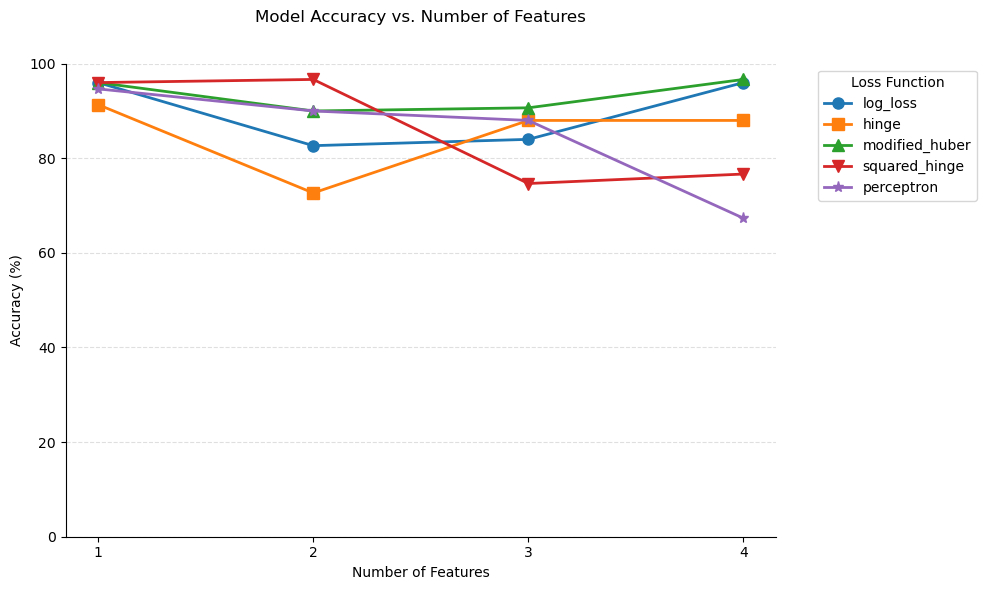

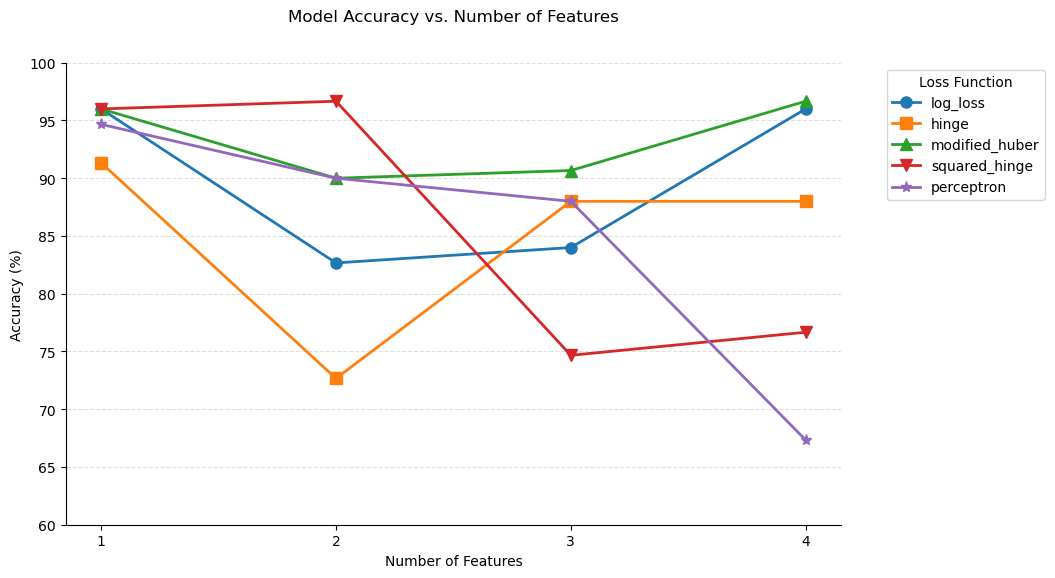

In [47]:
markers = ['o', 's', '^', 'v', '*'] 

plt.figure(figsize=(10, 6))

for i, loss in enumerate(loss_functions):
    loss_data = [item for item in plot_data if item[1] == loss]
    loss_data.sort(key=lambda x: x[2])
    
    features = [item[2] for item in loss_data]
    accuracies = [item[0] for item in loss_data]
    
    plt.plot(
        features, accuracies, 
        marker=markers[i % len(markers)], 
        linestyle='-', 
        markersize=8, 
        linewidth=2,
        label=loss
    )

plt.xlabel("Number of Features")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy vs. Number of Features", pad=30)

all_features = sorted(list(set([item[2] for item in plot_data])))
plt.xticks(all_features)
plt.ylim(0, 100)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.legend(title="Loss Function", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

for i, loss in enumerate(loss_functions):
    loss_data = [item for item in plot_data if item[1] == loss]
    loss_data.sort(key=lambda x: x[2])
    
    features = [item[2] for item in loss_data]
    accuracies = [item[0] for item in loss_data]
    
    plt.plot(
        features, accuracies, 
        marker=markers[i % len(markers)], 
        linestyle='-', 
        markersize=8, 
        linewidth=2,
        label=loss
    )

plt.xlabel("Number of Features")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy vs. Number of Features", pad=30)

all_features = sorted(list(set([item[2] for item in plot_data])))
plt.xticks(all_features)
plt.ylim(60, 100)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.legend(title="Loss Function", bbox_to_anchor=(1.05, 1))

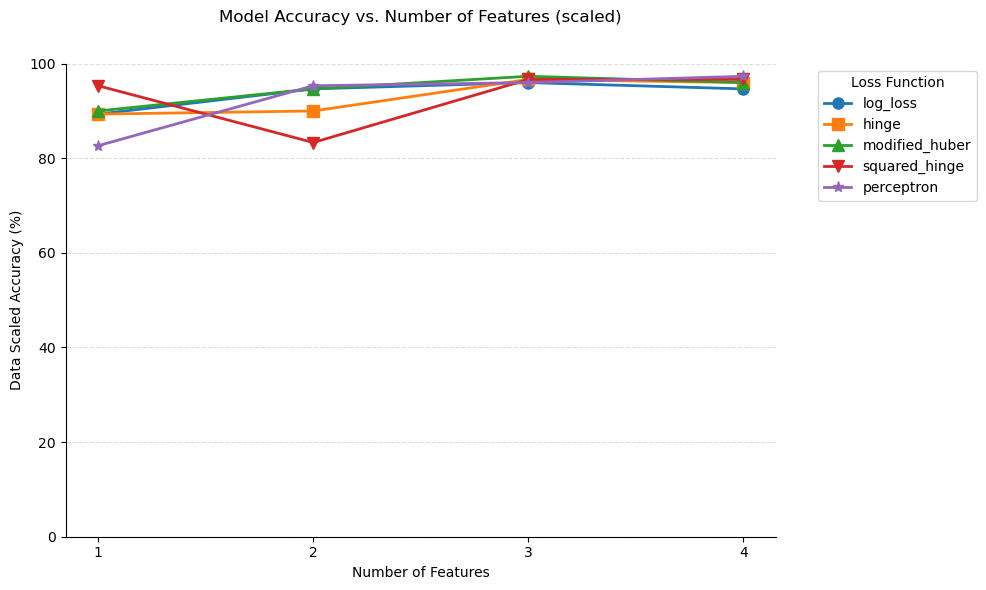

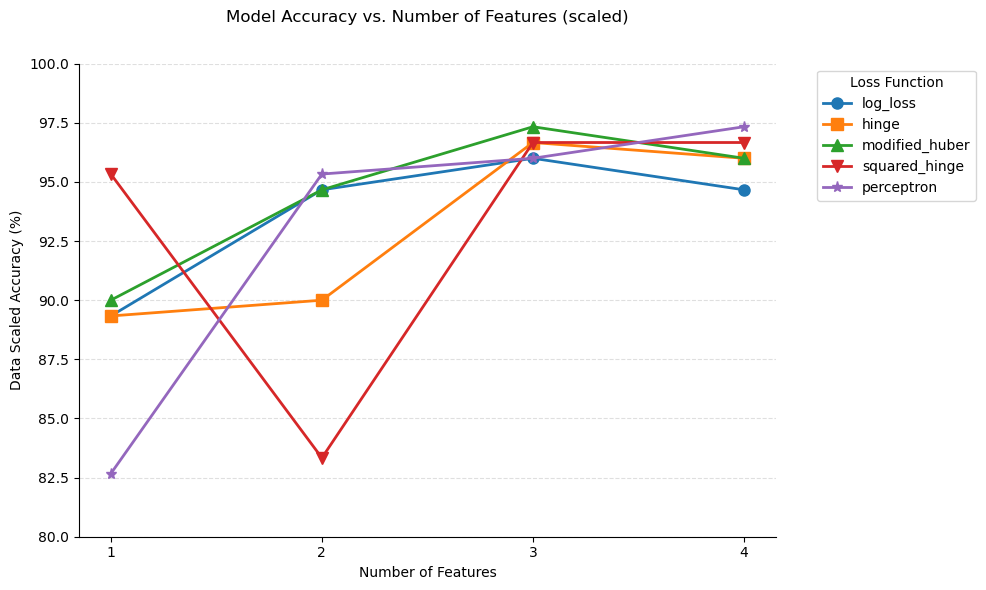

In [48]:
markers = ['o', 's', '^', 'v', '*'] 

plt.figure(figsize=(10, 6))

for i, loss in enumerate(loss_functions):
    loss_data = [item for item in plot_data_scaled if item[1] == loss]
    loss_data.sort(key=lambda x: x[2])
    
    features = [item[2] for item in loss_data]
    accuracies = [item[0] for item in loss_data]
    
    plt.plot(
        features, accuracies, 
        marker=markers[i], 
        linestyle='-', 
        markersize=8, 
        linewidth=2,
        label=loss
    )

plt.xlabel("Number of Features")
plt.ylabel("Data Scaled Accuracy (%)")
plt.title("Model Accuracy vs. Number of Features (scaled)", pad=30)

all_features = sorted(list(set([item[2] for item in plot_data_scaled])))
plt.xticks(all_features)
plt.ylim(0, 100)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.legend(title="Loss Function", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

for i, loss in enumerate(loss_functions):
    loss_data = [item for item in plot_data_scaled if item[1] == loss]
    loss_data.sort(key=lambda x: x[2])
    
    features = [item[2] for item in loss_data]
    accuracies = [item[0] for item in loss_data]
    
    plt.plot(
        features, accuracies, 
        marker=markers[i], 
        linestyle='-', 
        markersize=8, 
        linewidth=2,
        label=loss
    )

plt.xlabel("Number of Features")
plt.ylabel("Data Scaled Accuracy (%)")
plt.title("Model Accuracy vs. Number of Features (scaled)", pad=30)

all_features = sorted(list(set([item[2] for item in plot_data_scaled])))
plt.xticks(all_features)
plt.ylim(80, 100)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.legend(title="Loss Function", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

# Conclusions/Findings

Looking at the plot with accuracy in relation to the number of features used by the models, in the values obtained without scaling the data we get high fluctuations of accuracy as the number of features changed regardless of what loss function was used. If we scale the data and recalculate the accuracies we can see a general positive correlation where the model accuracy would increase and plateau around 96%. The only loss function that behaved abnormally was squared hinge where the accuracy heavily dropped when the number of features increased from one to two. This may have came from the squared hinge's punishing quadratic loss penalty for outliers.

A brief mention on true accuracy of the model. Since the dataset is only 150 values and there is no unique validation set the accuracy seen in the plots is most likely to be inflated from overfitting. Using a small dataset for a model may be possible using cross validation but to stay true to the assignment's parameters using the same dataset for training and validation will result in inaccurate accuracies.

So in all, there is a positive correlation in increasing the number of features to the overall accuracy of the models. The usage of different loss functions did not produce any noticable relevant changes except for squared hinge which is heavily punishing for outliers.